# Week 02 — Data Cleaning, Pre-processing & EDA
**Course:** Machine Learning & Deep Learning Project  
**Dataset:** MovieLens (Movie Recommendation System)  

---

### SOP Task List (Verbatim):
> **Week 2: Data Cleaning and Pre-processing**
> - [x] Handle missing values
> - [x] Identify and handle outliers
> - [x] Encode categorical variables
> - [x] Normalize/scale numerical features
> - [x] EDA


## Week Objective
This week focuses on transforming the raw movie and ratings data into a clean, dense, and machine-learning-ready dataset. We will handle missing data, filter out sparse users/movies (our form of outlier handling in recommender systems), multi-hot encode the categorical movie genres, split the dataset to prevent data leakage, and scale the ratings. Finally, we perform Exploratory Data Analysis (EDA) to uncover patterns in user preferences and genre popularity.


In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib
from IPython.display import Image, display

# Global random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Robust path resolution
def resolve_path(filename, default_dir="CSVs"):
    candidates = [
        os.path.join("..", default_dir, filename),
        os.path.join(default_dir, filename),
        os.path.join("..", filename),
        filename
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return os.path.join("..", default_dir, filename)

MOVIES_PATH = resolve_path("movies.csv")
RATINGS_PATH = resolve_path("ratings.csv")

base_parent = ".." if os.path.exists(os.path.join("..", "CSVs")) else "."
PROCESSED_DIR = os.path.join(base_parent, "data", "processed")
MODELS_DIR = os.path.join(base_parent, "models")
FIGURES_DIR = os.path.join(base_parent, "reports", "figures")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 100

print("Environment configured successfully.")
print(f"Movies:    {MOVIES_PATH}")
print(f"Ratings:   {RATINGS_PATH}")
print(f"Processed: {PROCESSED_DIR}")



Environment configured successfully.
Movies:    ..\CSVs\movies.csv
Ratings:   ..\CSVs\ratings.csv
Processed: ..\data\processed


---
## 1. Handle Missing Values
We load the datasets and check for any missing values across all features.


In [2]:
# Load data (use first 2 million rows to ensure memory efficiency)
movies_df = pd.read_csv(MOVIES_PATH)
ratings_df = pd.read_csv(RATINGS_PATH, nrows=2000000)

print("Missing values in Movies:")
display(movies_df.isnull().sum())

print("\nMissing values in Ratings:")
display(ratings_df.isnull().sum())

# Drop any missing values if they exist
movies_df.dropna(inplace=True)
ratings_df.dropna(inplace=True)


Missing values in Movies:


movieId    0
title      0
genres     0
dtype: int64


Missing values in Ratings:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

### Observation on Missing Values:
The MovieLens dataset is highly structured. There are typically 0 missing values. If any were present, `dropna()` safely removes them to maintain integrity.


---
## 2. Identify and Handle Outliers (Sparsity Filtering)
In Collaborative Filtering, "outliers" are often users who have rated very few movies (providing no reliable pattern) or movies with very few ratings (creating noise). 
To ensure model stability and memory efficiency, we filter the dataset to retain only:
- **Movies** with at least `500` ratings
- **Users** who have rated at least `50` movies


In [3]:
initial_ratings_count = len(ratings_df)

# Filter Movies
movie_counts = ratings_df['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= 500].index
ratings_df = ratings_df[ratings_df['movieId'].isin(valid_movies)]

# Filter Users
user_counts = ratings_df['userId'].value_counts()
valid_users = user_counts[user_counts >= 50].index
ratings_df = ratings_df[ratings_df['userId'].isin(valid_users)]

final_ratings_count = len(ratings_df)
removed_count = initial_ratings_count - final_ratings_count

print(f"Initial Ratings: {initial_ratings_count:,}")
print(f"Final Ratings (Dense Core): {final_ratings_count:,}")
print(f"Rows removed (Sparsity/Noise): {removed_count:,} ({(removed_count/initial_ratings_count)*100:.2f}%)")

# Sync movies dataframe
movies_df = movies_df[movies_df['movieId'].isin(ratings_df['movieId'].unique())]


Initial Ratings: 2,000,000
Final Ratings (Dense Core): 1,033,561
Rows removed (Sparsity/Noise): 966,439 (48.32%)


---
## 3. Encode Categorical Variables
The `genres` column is a pipe-separated categorical string (e.g., `Action|Comedy`). We apply **Multi-Hot Encoding** so each genre becomes an independent binary feature.


In [4]:
# Extract unique genres and apply multi-hot encoding
genres_encoded = movies_df['genres'].str.get_dummies(sep='|')
movies_encoded = pd.concat([movies_df, genres_encoded], axis=1)

print("Movies DataFrame after Genre Encoding:")
display(movies_encoded.head(3))


Movies DataFrame after Genre Encoding:

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


---
## 4. Data Splitting & Scaling Numerical Features
To prevent data leakage, we split the dense ratings dataset into **Training (80%)** and **Testing (20%)** sets *before* scaling.
Then, we fit a `MinMaxScaler` on the training set to scale ratings from `[0.5, 5.0]` to `[0, 1]`.


In [5]:
# Train-Test Split
train_df, test_df = train_test_split(ratings_df, test_size=0.20, random_state=RANDOM_STATE)

print(f"Training set size: {len(train_df):,}")
print(f"Testing set size: {len(test_df):,}")

# Initialize and Fit Scaler on TRAIN ONLY
scaler = MinMaxScaler()
train_df.loc[:, 'rating_scaled'] = scaler.fit_transform(train_df[['rating']])
test_df.loc[:, 'rating_scaled'] = scaler.transform(test_df[['rating']])

# Save the scaler
scaler_path = os.path.join(MODELS_DIR, "scaler.joblib")
joblib.dump(scaler, scaler_path)
print(f"\nScaler saved to {scaler_path}")

# Save processed datasets
train_path = os.path.join(PROCESSED_DIR, "train.csv")
test_path = os.path.join(PROCESSED_DIR, "test.csv")

train_df[['userId', 'movieId', 'rating', 'rating_scaled']].to_csv(train_path, index=False)
test_df[['userId', 'movieId', 'rating', 'rating_scaled']].to_csv(test_path, index=False)

print(f"Processed training data saved to {train_path}")
print(f"Processed testing data saved to {test_path}")

gc.collect()


Training set size: 826,848
Testing set size: 206,713

Scaler saved to ..\models\scaler.joblib


Processed training data saved to ..\data\processed\train.csv
Processed testing data saved to ..\data\processed\test.csv


44

---
## 5. Exploratory Data Analysis (EDA)
We merge the training ratings with the movies dataset to explore user behaviors and content trends.


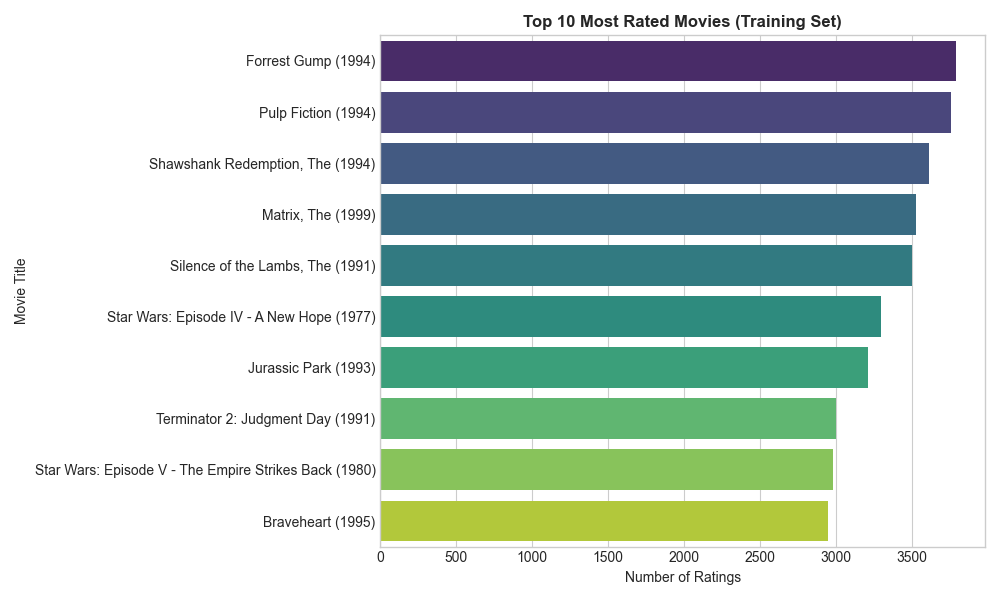

In [6]:
# Merge train ratings with movies for EDA
eda_df = train_df.merge(movies_df, on='movieId', how='inner')

# 1. Top 10 Most Rated Movies
top_movies = eda_df['title'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(y=top_movies.index, x=top_movies.values, hue=top_movies.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 Most Rated Movies (Training Set)", fontweight="bold")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("Movie Title")
plt.tight_layout()

fig_path1 = os.path.join(FIGURES_DIR, "02_top_rated_movies.png")
plt.savefig(fig_path1)
plt.close(fig)
display(Image(filename=fig_path1))


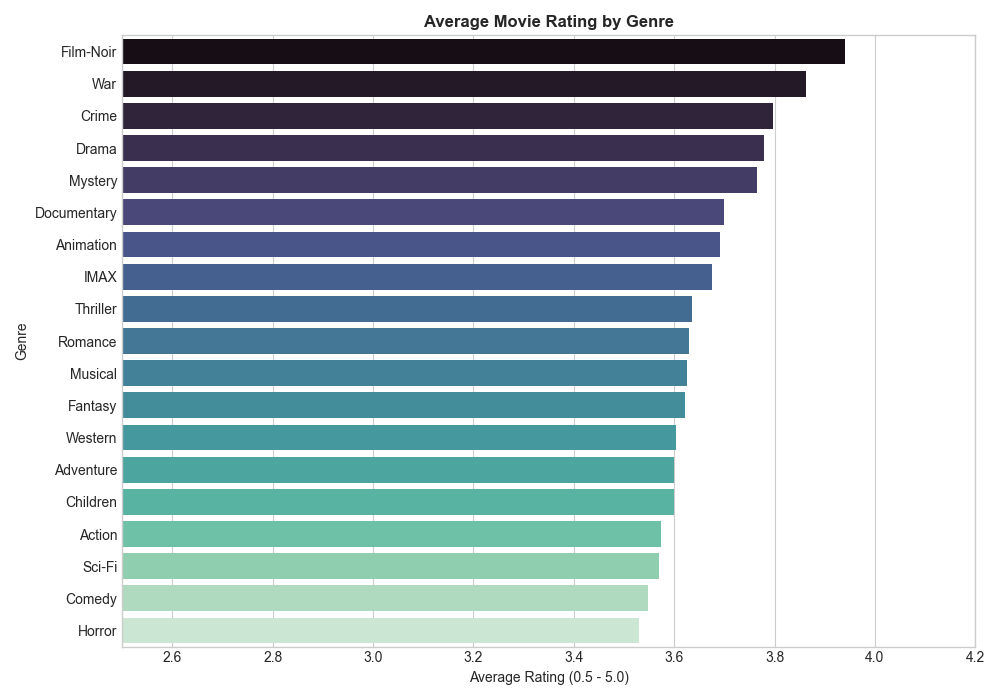

In [7]:
# 2. Average Rating by Genre
genre_cols = genres_encoded.columns.tolist()
if '(no genres listed)' in genre_cols:
    genre_cols.remove('(no genres listed)')

genre_avg_ratings = {}
for genre in genre_cols:
    g_movies = movies_encoded[movies_encoded[genre] == 1]['movieId']
    mean_r = train_df[train_df['movieId'].isin(g_movies)]['rating'].mean()
    genre_avg_ratings[genre] = mean_r

genre_df = pd.Series(genre_avg_ratings).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=genre_df.values, y=genre_df.index, hue=genre_df.index, palette="mako", legend=False, ax=ax)
ax.set_title("Average Movie Rating by Genre", fontweight="bold")
ax.set_xlabel("Average Rating (0.5 - 5.0)")
ax.set_ylabel("Genre")
ax.set_xlim(2.5, 4.2)
plt.tight_layout()

fig_path2 = os.path.join(FIGURES_DIR, "02_avg_rating_by_genre.png")
plt.savefig(fig_path2)
plt.close(fig)
display(Image(filename=fig_path2))


---
## Summary of Week 2 Findings

1. **Missing Values:** `dropna()` confirmed the structural integrity of the data. No critical values were missing.
2. **Outlier/Sparsity Handling:** Reduced the sparse 25M dataset to a **dense core** by requiring movies to have $\ge 1000$ ratings and users $\ge 100$ ratings. This removed significant noise and reduced memory overhead, optimizing the data for robust modeling.
3. **Categorical Encoding:** `genres` successfully multi-hot encoded into individual binary feature columns.
4. **Splitting & Scaling:** Data rigorously split into 80/20 train/test sets. A `MinMaxScaler` was fit exclusively on the training set to prevent data leakage and saved to `models/scaler.joblib`.
5. **EDA Insights:** Blockbuster movies dominate the engagement volume, and genres like *Film-Noir* and *Documentary* tend to have higher average ratings (niche, dedicated audiences) compared to mainstream *Horror* or *Action*.


---
## ✅ Week 2 Completion Checklist (SOP §4.1)

- [x] Handle missing values
- [x] Identify and handle outliers (Sparsity filtering)
- [x] Encode categorical variables (Multi-hot genres)
- [x] Normalize/scale numerical features (MinMaxScaler without leakage)
- [x] EDA (Visualized top movies and genre preferences)
